In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

Добавляем новые фичи.

In [3]:
service_cols = [
    "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]
data["num_services"] = (data[service_cols] == "Yes").sum(axis=1)

data.drop(columns=['gender'],inplace=True)
data['TotalCharges'] = pd.to_numeric(data.TotalCharges, errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(0)
data['Is_a_new_customer'] = (data['TotalCharges']==0).astype(int)

In [4]:
data.iloc[1:6,6:13]

,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV
1,No,DSL,Yes,No,Yes,No,No
2,No,DSL,Yes,Yes,No,No,No
3,No phone service,DSL,Yes,No,Yes,Yes,No
4,No,Fiber optic,No,No,No,No,No
5,Yes,Fiber optic,No,No,Yes,No,Yes


In [5]:

unique_values = data.iloc[:, 6:13].apply(lambda x: x.unique())
print(unique_values)


      MultipleLines InternetService       OnlineSecurity         OnlineBackup  \
0  No phone service             DSL                   No                  Yes   
1                No     Fiber optic                  Yes                   No   
2               Yes              No  No internet service  No internet service   

      DeviceProtection          TechSupport          StreamingTV  
0                   No                   No                   No  
1                  Yes                  Yes                  Yes  
2  No internet service  No internet service  No internet service  


In [6]:
print(data.iloc[:, 6:13].nunique())

MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
dtype: int64


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   SeniorCitizen      7043 non-null   int64  
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   tenure             7043 non-null   int64  
 5   PhoneService       7043 non-null   object 
 6   MultipleLines      7043 non-null   object 
 7   InternetService    7043 non-null   object 
 8   OnlineSecurity     7043 non-null   object 
 9   OnlineBackup       7043 non-null   object 
 10  DeviceProtection   7043 non-null   object 
 11  TechSupport        7043 non-null   object 
 12  StreamingTV        7043 non-null   object 
 13  StreamingMovies    7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  PaperlessBilling   7043 non-null   object 
 16  PaymentMethod      7043 

In [8]:
# data["tenure_segment"] = pd.cut(
#     data["tenure"],
#     bins=[-1, 3, 6, 12, 24, 60, 100],
#     labels=[
#         "0-3m",
#         "3-6m",
#         "6-12m",
#         "1-2y",
#         "2-5y",
#         "5y+"
#     ]
# )
# data.drop(columns=['tenure'])

In [9]:

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

data['Churn'] = LabelEncoder().fit_transform(data['Churn'])
# def object_to_int(dataSeries):
#     if dataSeries.dtype =='object':
#         dataSeries = LabelEncoder().fit_transform(dataSeries)
#     return dataSeries


# data = data.apply(lambda x: object_to_int(x))
data

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,num_services,Is_a_new_customer
0,7590-VHVEG,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,0
1,5575-GNVDE,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,2,0
2,3668-QPYBK,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,0
3,7795-CFOCW,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,0
4,9237-HQITU,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,5,0
7039,2234-XADUH,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,4,0
7040,4801-JZAZL,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,1,0
7041,8361-LTMKD,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1,0,0


Анализируя матрицу корреляций, попробую применить PCA для уменьшения размерности будущей матрицы X

*Корреляция 0.68 между PhoneService и MultipleLines. Очевидно, что нельзя иметь «несколько линий», не имея «телефонной связи». -> Оставит только MultipleLines, так как PhoneService избыточна для модели, как и использование PCA.* 

In [10]:
data.drop(columns=['PhoneService','customerID'], inplace=True)
# data.corr()['Churn'].abs().sort_values(ascending = False)

In [11]:
data

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,num_services,Is_a_new_customer
0,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,0
1,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2,0
2,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,0
3,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,0
4,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,Yes,Yes,24,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,5,0
7039,0,Yes,Yes,72,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,4,0
7040,0,Yes,Yes,11,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,1,0
7041,1,Yes,No,4,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1,0,0


In [12]:
from sklearn.preprocessing import StandardScaler
X = data.drop(columns=['Churn'])
y = data['Churn'].values

num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.30, random_state = 14, stratify=y)

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# pca = PCA()
# pca.fit(X_train.iloc[:,6:13])

# plt.plot(
#     np.cumsum(pca.explained_variance_ratio_),
#     marker='o'
# )
# plt.axhline(0.8, color='r', linestyle='--')
# plt.axhline(0.9, color='g', linestyle='--')
# plt.xlabel("Количество компонент")
# plt.ylabel("Накопленная доля дисперсии")
# plt.title("Explained Variance PCA")
# plt.show()

In [14]:
# np.cumsum(pca.explained_variance_ratio_)

In [15]:
X_train

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,num_services,Is_a_new_customer
783,0,No,No,1,No,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,52.20,52.20,1,0
5289,0,No,No,61,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,115.10,6993.65,6,0
2454,0,No,No,71,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Electronic check,24.55,1719.15,0,0
6801,0,Yes,Yes,19,Yes,Fiber optic,No,No,No,Yes,No,Yes,One year,Yes,Bank transfer (automatic),89.35,1686.85,2,0
6435,0,Yes,Yes,52,No phone service,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,50.20,2554.00,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4653,0,Yes,Yes,30,No phone service,DSL,No,No,No,Yes,Yes,Yes,Month-to-month,No,Credit card (automatic),51.20,1561.50,3,0
2628,0,No,No,1,No,Fiber optic,Yes,Yes,No,Yes,No,No,Month-to-month,Yes,Mailed check,83.40,83.40,3,0
6167,0,Yes,Yes,47,No,Fiber optic,Yes,No,Yes,No,No,Yes,Month-to-month,No,Electronic check,90.05,4137.20,3,0
4325,0,No,No,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),20.75,20.75,0,0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SeniorCitizen      7043 non-null   int64  
 1   Partner            7043 non-null   object 
 2   Dependents         7043 non-null   object 
 3   tenure             7043 non-null   int64  
 4   MultipleLines      7043 non-null   object 
 5   InternetService    7043 non-null   object 
 6   OnlineSecurity     7043 non-null   object 
 7   OnlineBackup       7043 non-null   object 
 8   DeviceProtection   7043 non-null   object 
 9   TechSupport        7043 non-null   object 
 10  StreamingTV        7043 non-null   object 
 11  StreamingMovies    7043 non-null   object 
 12  Contract           7043 non-null   object 
 13  PaperlessBilling   7043 non-null   object 
 14  PaymentMethod      7043 non-null   object 
 15  MonthlyCharges     7043 non-null   float64
 16  TotalCharges       7043 

*В связи с дисбалансом классов и отсутствием явных ограничений по издержкам для бизнеса, в качестве основного показателя оценки был выбран F1-мера. так как являтся баланосм между recall и precision. По желанию так же можно прибегнуть к recall потеря клиета стоит сильно выше, чем лишний раз дать скидку клиенту которой и так не собирался ухоить, например.*

## Baseline

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, ComplementNB
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

ratio = (y_train == 0).sum() / (y_train == 1).sum()

service_cols = [
    "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]
other_cat_cols = [c for c in cat_cols if c not in service_cols]

preprocessor_pca = ColumnTransformer(
    transformers=[
        (
            "service_pca",
            Pipeline([
                ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
                ("scaler", StandardScaler(with_mean=False)),
                ("pca", PCA(n_components=5, random_state=42))
            ]),
            service_cols
        ),
        (
            "other_cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            other_cat_cols
        ),
        (
            "num",
            StandardScaler(),
            num_cols
        )
    ],
    remainder="drop"
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat_cols",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            cat_cols
        ),
        (
            "num",
            StandardScaler(),
            num_cols
        )
    ],
    remainder="drop"
)


models = {
    "LogReg": Pipeline([
        ("preprocess", preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", max_iter = 1000))
    ]),
    "LogReg+PCA": Pipeline([
        ("preprocess", preprocessor_pca),
        ("clf", LogisticRegression(class_weight="balanced", max_iter = 1000))
    ]),
    "SVM": Pipeline([
        ("preprocess", preprocessor),
        ("clf", SVC(class_weight="balanced"))
    ]),
    "DecisionTree": Pipeline([
        ("preprocess", preprocessor),
        ("clf", DecisionTreeClassifier(class_weight="balanced"))
    ]),
    "RandomForest": Pipeline([
        ("preprocess", preprocessor),
        ("clf", RandomForestClassifier(class_weight="balanced"))
    ]),
    "GradientBoosting": Pipeline([
        ("preprocess", preprocessor),
        ("clf", GradientBoostingClassifier())
    ]),
    "NaiveBayes": Pipeline([
        ("preprocess", preprocessor),
        ("clf", GaussianNB())
    ]),
    "XGB": Pipeline([
        ("preprocess", preprocessor),
        ("clf", XGBClassifier(scale_pos_weight=ratio))
    ])
}

from sklearn.metrics import precision_recall_fscore_support

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="binary"
    )

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }


for name, metrics in results.items():
    print(f"{name}: Precision={metrics['Precision']:.3f}, Recall={metrics['Recall']:.3f}, F1={metrics['F1']:.3f}")

LogReg: Precision=0.516, Recall=0.815, F1=0.632
LogReg+PCA: Precision=0.513, Recall=0.816, F1=0.630
SVM: Precision=0.520, Recall=0.802, F1=0.631
DecisionTree: Precision=0.479, Recall=0.503, F1=0.490
RandomForest: Precision=0.618, Recall=0.478, F1=0.539
GradientBoosting: Precision=0.661, Recall=0.538, F1=0.593
NaiveBayes: Precision=0.384, Recall=0.938, F1=0.545
XGB: Precision=0.533, Recall=0.683, F1=0.598


*Baseline - f1 = 0.63. Попробую настроить гиперпараметры для LogReg и для XGBoost. Так же стоит обрать внимание, что PCA  не дала значимого результата.*

### LogReg


In [18]:
log_reg = Pipeline([
        ("preprocess", preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", max_iter = 1000, solver='saga'))
    ])

In [19]:
param_grid = {
    "clf__penalty": ["elasticnet"],
    "clf__l1_ratio": np.linspace(0, 1, 11),
    "clf__C": [0.01, 0.1, 0.5, 1, 2, 10,20,50],
    "clf__max_iter": [1000]
}

grid = GridSearchCV(param_grid= param_grid,
                    estimator=log_reg,
                    scoring='f1',
                    cv = 5,
                    n_jobs=-1,)

grid.fit(X_train,y_train)
print(grid.best_params_)
print(grid.best_score_)

{'clf__C': 1, 'clf__l1_ratio': np.float64(0.6000000000000001), 'clf__max_iter': 1000, 'clf__penalty': 'elasticnet'}
0.627341078805959


In [20]:
final_logreg = grid.best_estimator_

In [21]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = np.zeros(len(y_train))

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    final_logreg.fit(X_tr, y_tr)

    oof_proba[val_idx] = final_logreg.predict_proba(X_val)[:, 1]

In [22]:
from sklearn.metrics import f1_score
thresholds = np.linspace(0.1, 0.9, 81)
scores = []

for t in thresholds:
    y_pred = (oof_proba >= t).astype(int)
    scores.append(f1_score(y_train, y_pred))

best_t = thresholds[np.argmax(scores)]
best_f1 = max(scores)

print(f"Best threshold: {best_t:.3f}")
print(f"OOF F1: {best_f1:.4f}")

Best threshold: 0.570
OOF F1: 0.6310


In [35]:
y_proba_log_reg = final_logreg.predict_proba(X_test)[:, 1]
y_pred_log_reg = (y_proba_log_reg >= best_t).astype(int)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_log_reg))

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1552
           1       0.52      0.79      0.63       561

    accuracy                           0.75      2113
   macro avg       0.72      0.77      0.72      2113
weighted avg       0.81      0.75      0.77      2113



Text(0.5, 36.72222222222221, 'Predicted')

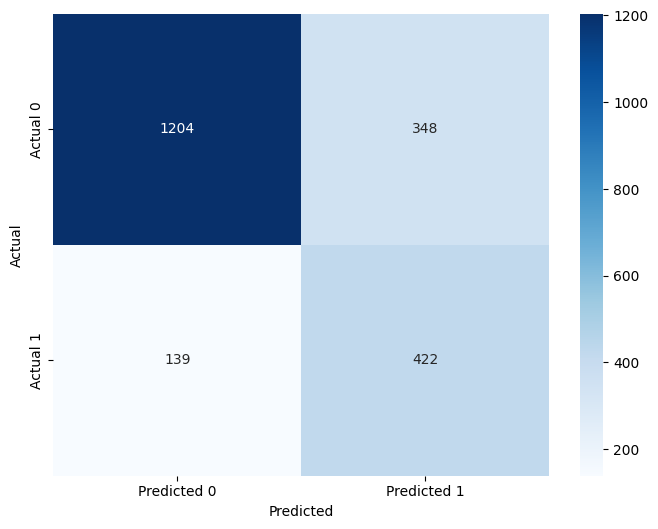

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_log_reg)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')

### XGBoost

In [25]:
import optuna
from sklearn.metrics import f1_score
from xgboost.callback import EarlyStopping

import xgboost as xgb

def objective(trial):
    

    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("lr", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "tree_method": "hist",
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for tr_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        X_tr_p = preprocessor.fit_transform(X_tr)
        X_val_p = preprocessor.transform(X_val)

        dtrain = xgb.DMatrix(X_tr_p, label=y_tr)
        dval = xgb.DMatrix(X_val_p, label=y_val)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=1000,
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        preds = (model.predict(dval) > 0.5).astype(int)
        scores.append(f1_score(y_val, preds))

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

f:\MiniConda\envs\Churn_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-01 11:45:25,504] A new study created in memory with name: no-name-a090af0e-c56c-4df8-a3fa-4858354de7f7
[I 2026-03-01 11:45:26,624] Trial 0 finished with value: 0.5556063019554559 and parameters: {'max_depth': 6, 'lr': 0.1703241126525508, 'subsample': 0.9120074824142879, 'colsample': 0.9561444903407278, 'min_child_weight': 2}. Best is trial 0 with value: 0.5556063019554559.
[I 2026-03-01 11:45:40,302] Trial 1 finished with value: 0.5504143002232506 and parameters: {'max_depth': 7, 'lr': 0.002474559254624329, 'subsample': 0.7713477017081236, 'colsample': 0.9310211994112362, 'min_child_weight': 2}. Best is trial 0 with value: 0.5556063019554559.
[I 2026-03-01 11:45:42,075] Trial 2 finished with value: 0.5676214866686583 and paramet

In [26]:
print(study.best_value)
print(study.best_params)

0.5914628345341144
{'max_depth': 3, 'lr': 0.009337210530039627, 'subsample': 0.7139673256696099, 'colsample': 0.7284196244947793, 'min_child_weight': 2}


In [27]:
xgb = Pipeline([
        ("preprocess", preprocessor),
        ("clf", XGBClassifier(
    max_depth= 4,
    learning_rate= 0.0071794089760776735,
    subsample= 0.6160062458285304,
    colsample_bytree= 0.907970452378792,
    min_child_weight= 1,
    objective= "binary:logistic",
    eval_metric= "logloss",
    random_state= 42,
    tree_method= "hist",
    scale_pos_weight= ratio
))
    ])



xgb.fit(X_train,y_train)

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_cols', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
y_proba_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1552
           1       0.51      0.82      0.63       561

    accuracy                           0.74      2113
   macro avg       0.71      0.77      0.72      2113
weighted avg       0.81      0.74      0.76      2113



In [29]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = np.zeros(len(y_train))

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    xgb.fit(X_tr, y_tr)

    oof_proba[val_idx] = xgb.predict_proba(X_val)[:, 1]

from sklearn.metrics import f1_score
thresholds = np.linspace(0.1, 0.9, 81)
scores = []

for t in thresholds:
    y_pred = (oof_proba >= t).astype(int)
    scores.append(f1_score(y_train, y_pred))

best_t = thresholds[np.argmax(scores)]
best_f1 = max(scores)

xgb.fit(X_train,y_train)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb = (y_proba_xgb > best_t).astype(int)

print(f"Best threshold: {best_t:.3f}")
print(f"OOF F1: {best_f1:.4f}")
print(classification_report(y_test, y_pred_xgb))

Best threshold: 0.520
OOF F1: 0.6254
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1552
           1       0.53      0.79      0.63       561

    accuracy                           0.76      2113
   macro avg       0.72      0.77      0.73      2113
weighted avg       0.81      0.76      0.77      2113



Text(0.5, 36.72222222222221, 'Predicted')

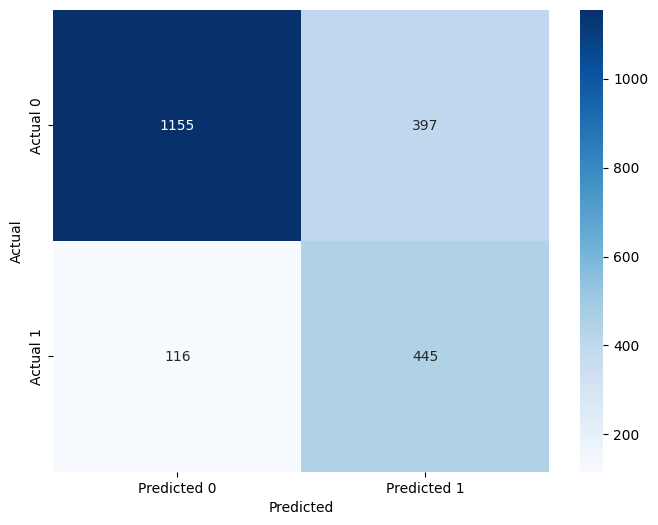

In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_xgb)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')

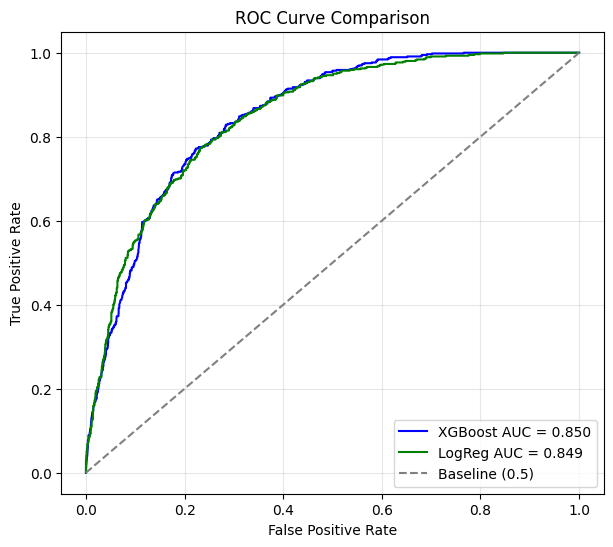

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Расчет метрик для XGBoost
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

# 2. Расчет метрик для Logistic Regression
roc_auc_logreg = roc_auc_score(y_test, y_proba_log_reg)
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_log_reg)

# 3. Визуализация
plt.figure(figsize=(7, 6))

# Кривая XGBoost
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost AUC = {roc_auc_xgb:.3f}', color='blue')

# Кривая LogReg
plt.plot(fpr_logreg, tpr_logreg, label=f'LogReg AUC = {roc_auc_logreg:.3f}', color='green')

# Пунктирная линия (случайный классификатор)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline (0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

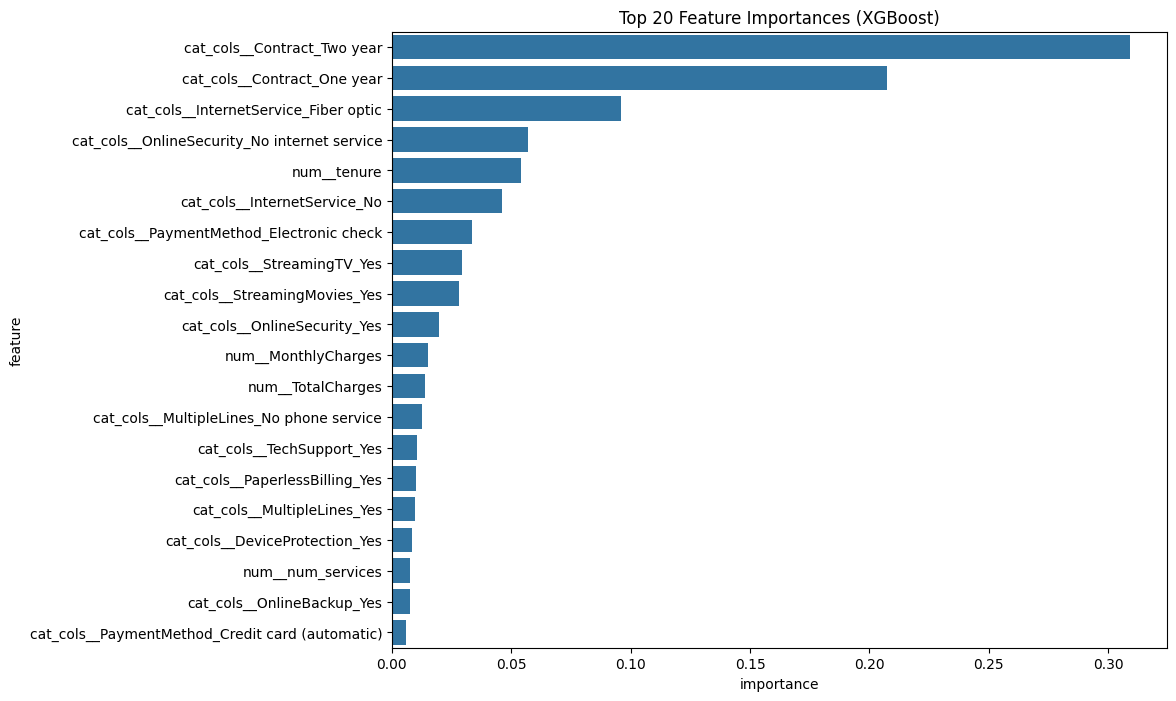

                                         feature  importance
19                   cat_cols__Contract_Two year    0.309129
18                   cat_cols__Contract_One year    0.207407
4          cat_cols__InternetService_Fiber optic    0.096025
6   cat_cols__OnlineSecurity_No internet service    0.057045
25                                   num__tenure    0.053950
5                   cat_cols__InternetService_No    0.046175
22      cat_cols__PaymentMethod_Electronic check    0.033609
15                     cat_cols__StreamingTV_Yes    0.029151
17                 cat_cols__StreamingMovies_Yes    0.028275
7                   cat_cols__OnlineSecurity_Yes    0.019566


In [41]:
importance = xgb.named_steps['clf'].feature_importances_
feature_names = preprocessor.get_feature_names_out() 


feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance  
}).sort_values('importance', ascending=False)


plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(20))
plt.title('Top 20 Feature Importances (XGBoost)')
plt.show()

print(feature_importance.head(10))

*Предположение о типе контракта, как о самом влиятельном критериии оказалось верным.
Стоит обратить внимание на наличие у клиетов оптоволокна - является значительным критерием для предсказания оттока. *

XGB и LogReg  дали одинаковые результаты. В финальную модель использую LogReg, так как ее легче интерпритировать.

In [46]:
import json
model_params = final_logreg.named_steps['clf'].get_params()

# Фильтруем параметры, оставляя только те, что можно сериализовать в JSON
serializable_params = {k: v for k, v in model_params.items() 
                    if isinstance(v, (int, float, str, bool, list, dict, type(None)))}

# Сохраняем в файл
with open('../config/model.json', 'w') as f:
    json.dump(serializable_params, f, indent=4)